In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('hr.csv')
df.columns = df.columns.str.lower()
df.shape
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 15 columns):
 #   Column              Dtype  
---  ------              -----  
 0   employee_id         str    
 1   full_name           str    
 2   department          str    
 3   job_title           str    
 4   hire_date           str    
 5   performance_rating  str    
 6   experience_years    int64  
 7   status              str    
 8   work_mode           str    
 9   salary              float64
 10  year                int64  
 11  country             str    
 12  city                str    
 13  age                 int64  
 14  job_level           str    
dtypes: float64(1), int64(3), str(11)
memory usage: 228.9 MB


,employee_id,full_name,department,job_title,hire_date,performance_rating,experience_years,status,work_mode,salary,year,country,city,age,job_level
0,EMP0000001,Heinz-Georg Eimer,Sales,Business Development,2023-01-31,Satisfactory,8,Active,On-site,92992.0,2023,Germany,Munich,32,Mid
1,EMP0000002,Maartje van den Nuwenhuysen-Geertsen,HR,HR Manager,2008-11-07,Good,11,Active,On-site,112318.0,2008,Netherlands,Eindhoven,43,Senior
2,EMP0000003,Sara Sureda Figueroa,HR,Talent Specialist,2016-03-19,Needs Improvement,15,Active,On-site,111121.0,2016,Spain,Seville,43,Senior
3,EMP0000004,Luce Sanchez,Operations,Operations Director,2024-04-03,Good,1,Active,Hybrid,49012.0,2024,France,Marseille,23,Junior
4,EMP0000005,William Jennings,Sales,Regional Lead,2024-11-17,Good,2,Active,On-site,57553.0,2024,United Kingdom,Edinburgh,31,Junior


In [3]:
df.describe()

,experience_years,salary,year,age
count,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06
mean,6.274432e+00,8.994836e+04,2.020040e+03,3.141359e+01
std,5.655506e+00,4.689432e+04,4.992028e+00,6.736600e+00
min,-5.000000e+00,-9.993200e+04,2.008000e+03,2.100000e+01
25%,2.000000e+00,5.371000e+04,2.017000e+03,2.700000e+01
50%,5.000000e+00,8.082900e+04,2.022000e+03,3.000000e+01
75%,8.000000e+00,1.041800e+05,2.024000e+03,3.500000e+01
max,3.000000e+01,3.221070e+05,2.026000e+03,6.600000e+01


In [4]:
df.isnull().sum()

employee_id              0
full_name                0
department               0
job_title                0
hire_date                0
performance_rating    3333
experience_years         0
status                   0
work_mode                0
salary                   0
year                     0
country                  0
city                     0
age                      0
job_level                0
dtype: int64

In [5]:
df['performance_rating'] = (df['performance_rating'].fillna('Unknown'))
df.isnull().sum()

employee_id           0
full_name             0
department            0
job_title             0
hire_date             0
performance_rating    0
experience_years      0
status                0
work_mode             0
salary                0
year                  0
country               0
city                  0
age                   0
job_level             0
dtype: int64

In [6]:
df.duplicated().sum()
df['employee_id'].duplicated().sum()

np.int64(0)

In [7]:
df['hire_date']=pd.to_datetime(df['hire_date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 15 columns):
 #   Column              Dtype         
---  ------              -----         
 0   employee_id         str           
 1   full_name           str           
 2   department          str           
 3   job_title           str           
 4   hire_date           datetime64[us]
 5   performance_rating  str           
 6   experience_years    int64         
 7   status              str           
 8   work_mode           str           
 9   salary              float64       
 10  year                int64         
 11  country             str           
 12  city                str           
 13  age                 int64         
 14  job_level           str           
dtypes: datetime64[us](1), float64(1), int64(3), str(10)
memory usage: 228.9 MB


In [8]:
df[df['experience_years']<0].shape

(2421, 15)

In [9]:
df['experience_years'] = (df['experience_years'].abs())
df[df['experience_years']<0].shape

(0, 15)

In [11]:
df[df['salary']<0].shape

(3333, 15)

In [13]:
salary_median_group = (
    df[df['salary'] > 0]
    .groupby(['job_level','department'])['salary'].median())
mask = df['salary'] < 0

df.loc[mask,'salary'] = (
    df.loc[mask,['job_level','department']]
    .apply(
        lambda x:
        salary_median_group[
            (x['job_level'],
             x['department'])],axis=1))

df[df['salary']<0].shape

(0, 15)

In [14]:
categorical_columns = [
    'department',
    'job_title',
    'performance_rating',
    'status',
    'work_mode',
    'country',
    'city',
    'job_level'
]

for col in categorical_columns:
    print(col, df[col].nunique())

department 5
job_title 25
performance_rating 5
status 4
work_mode 3
country 7
city 35
job_level 4


In [15]:
(df['hire_date'].dt.year == df['year']).value_counts()

True    2000000
Name: count, dtype: int64

In [16]:
df.groupby('job_level')['experience_years'].describe()

,count,mean,std,min,25%,50%,75%,max
job_level,,,,,,,,
Director,100720.0,22.972865,4.403252,0.0,19.0,23.0,27.0,30.0
Junior,758236.0,1.502532,1.119550,0.0,1.0,2.0,3.0,5.0
Mid,761754.0,5.994108,1.423236,0.0,5.0,6.0,7.0,8.0
Senior,379290.0,11.981057,2.040022,0.0,10.0,12.0,14.0,15.0


In [17]:
df.groupby('job_level')['salary'].median()

job_level
Director    225491.5
Junior       50426.0
Mid          86310.0
Senior      140860.5
Name: salary, dtype: float64

In [18]:

Q1_salary = df['salary'].quantile(0.25)
Q3_salary = df['salary'].quantile(0.75)

IQR_salary = Q3_salary - Q1_salary

lower_salary = Q1_salary - 1.5 * IQR_salary
upper_salary = Q3_salary + 1.5 * IQR_salary

salary_outlier = df[
    (df['salary'] < lower_salary) |
    (df['salary'] > upper_salary)
]

print("Q1:", Q1_salary)
print("Q3:", Q3_salary)
print("IQR:", IQR_salary)
print("Lower Bound:", lower_salary)
print("Upper Bound:", upper_salary)
print("Outliers:", len(salary_outlier))

Q1: 53780.0
Q3: 104271.0
IQR: 50491.0
Lower Bound: -21956.5
Upper Bound: 180007.5
Outliers: 100178


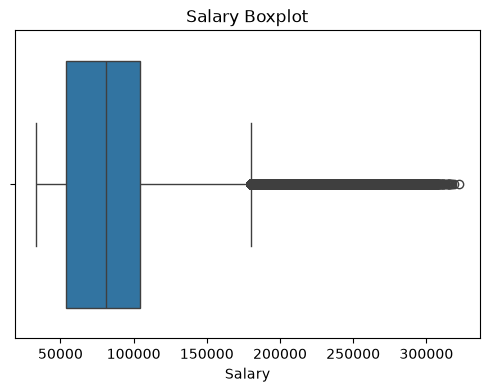

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['salary'])

plt.title('Salary Boxplot')
plt.xlabel('Salary')

plt.show()

In [20]:

Q1_exp = df['experience_years'].quantile(0.25)
Q3_exp = df['experience_years'].quantile(0.75)

IQR_exp = Q3_exp - Q1_exp

lower_exp = Q1_exp - 1.5 * IQR_exp
upper_exp = Q3_exp + 1.5 * IQR_exp

experience_outlier = df[
    (df['experience_years'] < lower_exp)|
    (df['experience_years'] > upper_exp)]
print("Lower Bound:", lower_exp)
print("Upper Bound:", upper_exp)
print("Total Outliers:", len(experience_outlier))

Lower Bound: -7.0
Upper Bound: 17.0
Total Outliers: 87049


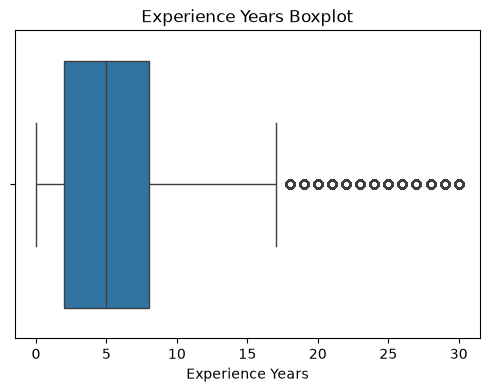

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['experience_years'])

plt.title('Experience Years Boxplot')
plt.xlabel('Experience Years')
plt.show()

In [22]:
experience_outlier['job_level'].value_counts()

job_level
Director    87049
Name: count, dtype: int64

In [23]:
experience_outlier.groupby('job_level')['experience_years'].describe()

,count,mean,std,min,25%,50%,75%,max
job_level,,,,,,,,
Director,87049.0,24.014187,3.748993,18.0,21.0,24.0,27.0,30.0


In [24]:
experience_outlier[['experience_years', 'age']].describe()

,experience_years,age
count,87049.000000,87049.000000
mean,24.014187,51.015417
std,3.748993,4.833290
min,18.000000,38.000000
25%,21.000000,47.000000
50%,24.000000,51.000000
75%,27.000000,54.000000
max,30.000000,66.000000


In [25]:

Q1_age = df['age'].quantile(0.25)
Q3_age = df['age'].quantile(0.75)

IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

age_outlier = df[
    (df['age'] < lower_age) |
    (df['age'] > upper_age)]

print("Lower Bound:", lower_age)
print("Upper Bound:", upper_age)
print("Total Outliers:", len(age_outlier))

Lower Bound: 15.0
Upper Bound: 47.0
Total Outliers: 68675


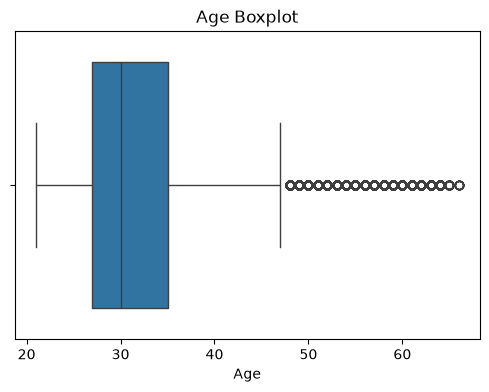

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['age'])

plt.title('Age Boxplot')
plt.xlabel('Age')

plt.show()

In [27]:
age_outlier['job_level'].value_counts()

job_level
Director    66745
Senior       1930
Name: count, dtype: int64

In [28]:
age_outlier.groupby('job_level')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
job_level,,,,,,,,
Director,66745.0,53.001483,3.584444,48.0,50.0,53.0,55.0,66.0
Senior,1930.0,48.505181,0.726613,48.0,48.0,48.0,49.0,51.0


In [29]:
age_outlier[['age', 'experience_years']].describe()

,age,experience_years
count,68675.000000,68675.000000
mean,52.875122,24.781158
std,3.613057,3.966984
min,48.000000,0.000000
25%,50.000000,22.000000
50%,52.000000,25.000000
75%,55.000000,28.000000
max,66.000000,30.000000


In [ ]:
department_distribution = (
    df['department']
    .value_counts()
    .rename_axis('department')
    .reset_index(name='total_employee'))

department_distribution['percentage'] = (
    department_distribution['total_employee']
    / len(df) * 100
).round(2)

department_distribution

,department,total_employee,percentage
0,Sales,600633,30.03
1,IT,499325,24.97
2,Operations,400595,20.03
3,Finance,299955,15.00
4,HR,199492,9.97


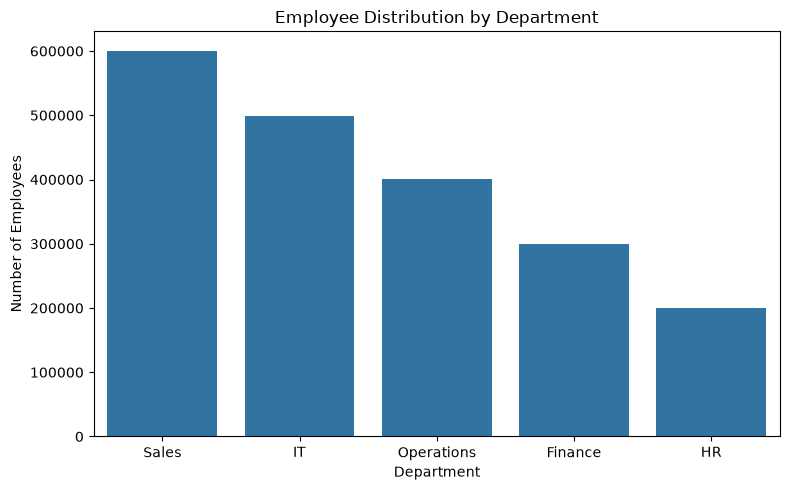

In [35]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=department_distribution,
    x='department',
    y='total_employee')

plt.title('Employee Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.show()

In [36]:
joblevel_distribution = (
    df['job_level']
    .value_counts()
    .rename_axis('job_level')
    .reset_index(name='total_employee'))

joblevel_distribution['percentage'] = (
    joblevel_distribution['total_employee']
    / len(df) * 100
).round(2)

joblevel_distribution

,job_level,total_employee,percentage
0,Mid,761754,38.09
1,Junior,758236,37.91
2,Senior,379290,18.96
3,Director,100720,5.04


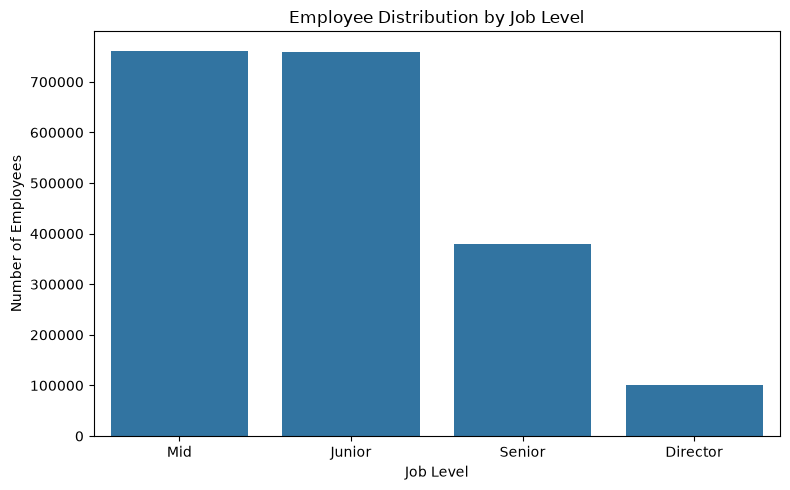

In [37]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=joblevel_distribution,
    x='job_level',
    y='total_employee')

plt.title('Employee Distribution by Job Level')
plt.xlabel('Job Level')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.show()

In [38]:
workmode_distribution = (
    df['work_mode']
    .value_counts()
    .rename_axis('work_mode')
    .reset_index(name='total_employee'))

workmode_distribution['percentage'] = (
    workmode_distribution['total_employee']
    / len(df) * 100
).round(2)

workmode_distribution

,work_mode,total_employee,percentage
0,On-site,1099347,54.97
1,Remote,550096,27.50
2,Hybrid,350557,17.53


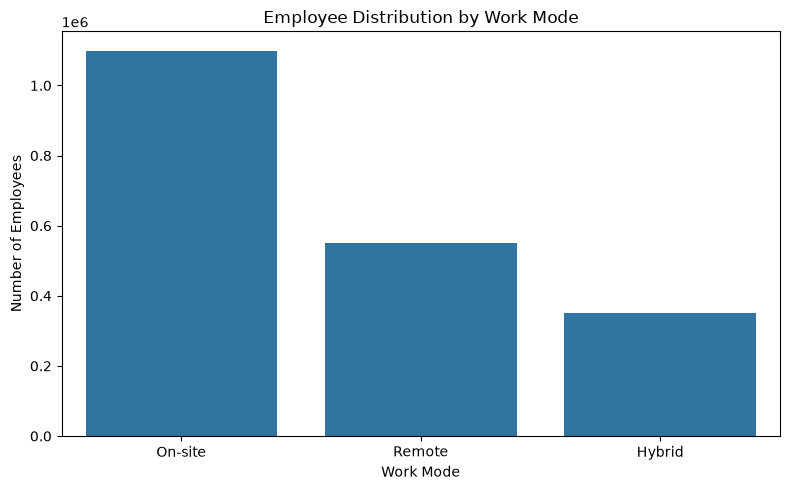

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=workmode_distribution,
    x='work_mode',
    y='total_employee')

plt.title('Employee Distribution by Work Mode')
plt.xlabel('Work Mode')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.show()

In [40]:
status_distribution = (
    df['status']
    .value_counts()
    .rename_axis('status')
    .reset_index(name='total_employee'))

status_distribution['percentage'] = (
    status_distribution['total_employee']
    / len(df) * 100
).round(2)

status_distribution

,status,total_employee,percentage
0,Active,1793596,89.68
1,Resigned,160000,8.00
2,Terminated,45951,2.30
3,Retired,453,0.02


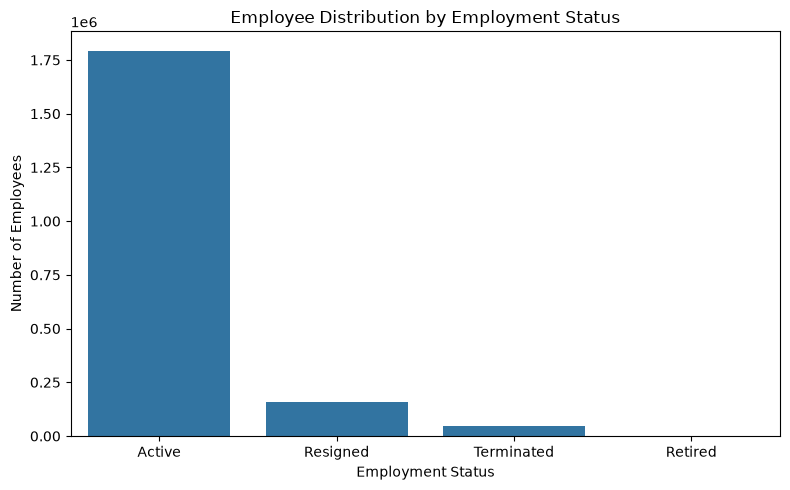

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=status_distribution,
    x='status',
    y='total_employee')

plt.title('Employee Distribution by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.show()

In [ ]:
performance_distribution = (
    df['performance_rating']
    .value_counts()
    .rename_axis('performance_rating')
    .reset_index(name='total_employee'))

performance_distribution['percentage'] = (
    performance_distribution['total_employee']
    / len(df) * 100
).round(2)

performance_distribution

,performance_rating,total_employee,percentage
0,Good,998968,49.95
1,Satisfactory,558931,27.95
2,Excellent,298844,14.94
3,Needs Improvement,139924,7.00
4,Unknown,3333,0.17


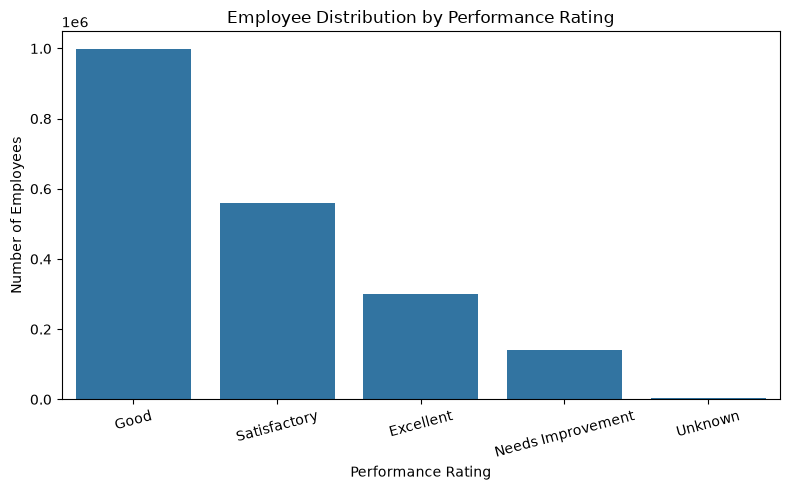

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=performance_distribution,
    x='performance_rating',
    y='total_employee')

plt.title('Employee Distribution by Performance Rating')
plt.xlabel('Performance Rating')
plt.ylabel('Number of Employees')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [44]:
country_distribution = (
    df['country']
    .value_counts()
    .rename_axis('country')
    .reset_index(name='total_employee'))

country_distribution['percentage'] = (
    country_distribution['total_employee']
    / len(df) * 100
).round(2)

country_distribution

,country,total_employee,percentage
0,United Kingdom,499659,24.98
1,Germany,440816,22.04
2,France,400162,20.01
3,Spain,259754,12.99
4,Italy,199872,9.99
5,Netherlands,139392,6.97
6,Poland,60345,3.02


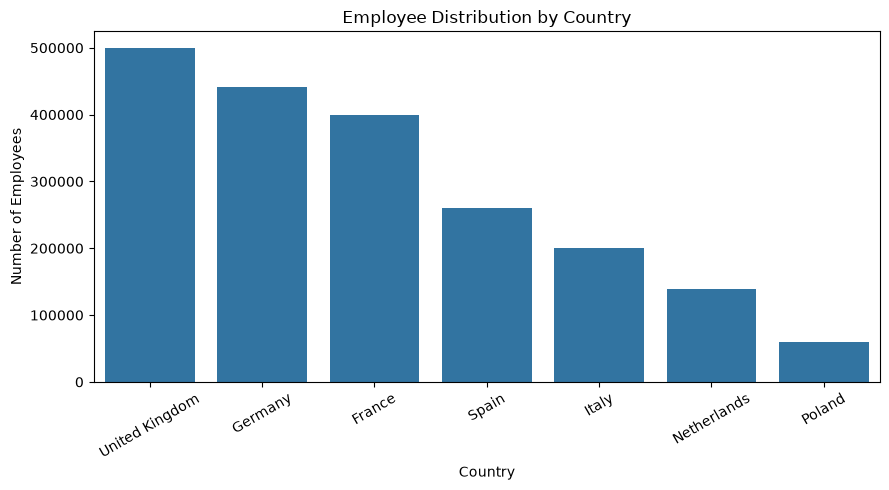

In [ ]:
plt.figure(figsize=(9,5))
sns.barplot(
    data=country_distribution,
    x='country',
    y='total_employee')

plt.title('Employee Distribution by Country')
plt.xlabel('Country')
plt.ylabel('Number of Employees')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
city_distribution = (
    df['city']
    .value_counts()
    .rename_axis('city')
    .reset_index(name='total_employee'))

city_distribution['percentage'] = (
    city_distribution['total_employee']
    / len(df) * 100
).round(2)

city_distribution

,city,total_employee,percentage
0,Leeds,100203,5.01
1,Edinburgh,100008,5.00
2,Birmingham,99993,5.00
3,London,99768,4.99
4,Manchester,99687,4.98
5,Hamburg,88429,4.42
6,Frankfurt,88362,4.42
7,Cologne,88143,4.41
8,Munich,87968,4.40
9,Berlin,87914,4.40


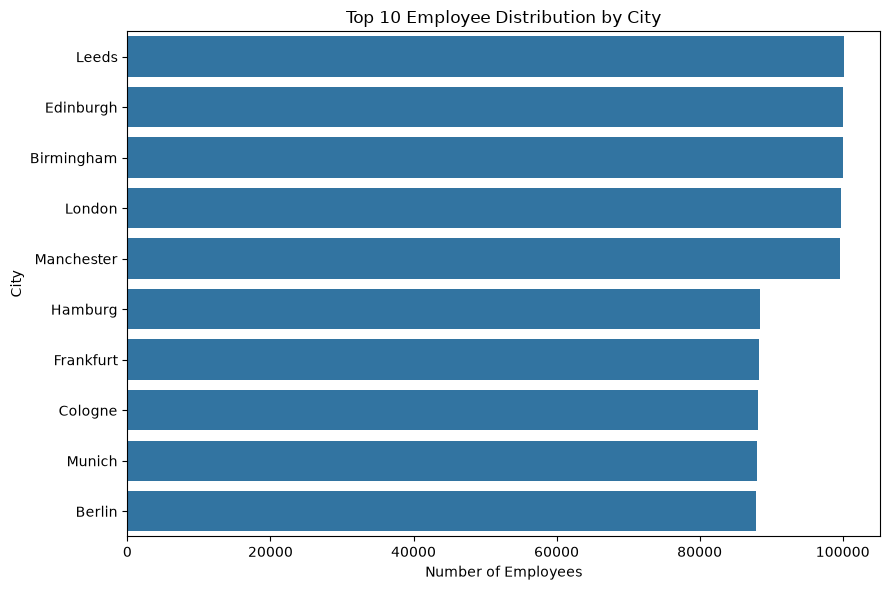

In [47]:
top10_city = city_distribution.head(10)

plt.figure(figsize=(9,6))
sns.barplot(
    data=top10_city,
    x='total_employee',
    y='city')

plt.title('Top 10 Employee Distribution by City')
plt.xlabel('Number of Employees')
plt.ylabel('City')
plt.tight_layout()
plt.show()

In [48]:
df['salary'].describe()

count    2.000000e+06
mean     9.018084e+04
std      4.656802e+04
min      3.330800e+04
25%      5.378000e+04
50%      8.090650e+04
75%      1.042710e+05
max      3.221070e+05
Name: salary, dtype: float64

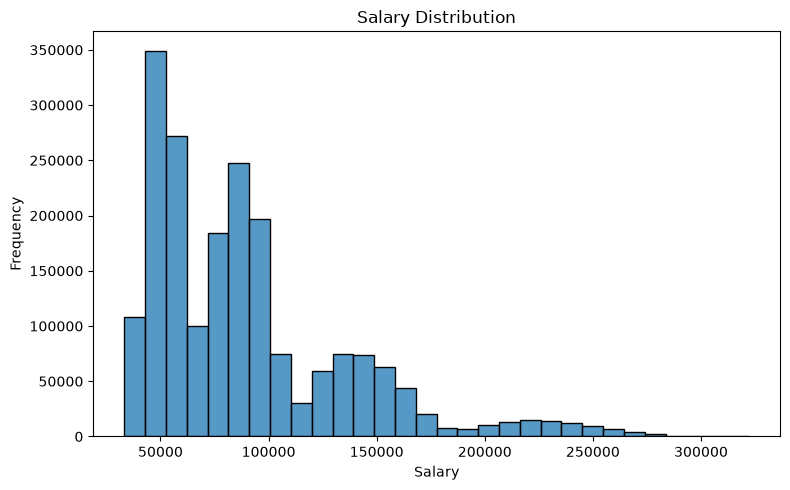

In [49]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x='salary',
    bins=30)

plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [50]:
df['experience_years'].describe()

count    2.000000e+06
mean     6.281716e+00
std      5.647415e+00
min      0.000000e+00
25%      2.000000e+00
50%      5.000000e+00
75%      8.000000e+00
max      3.000000e+01
Name: experience_years, dtype: float64

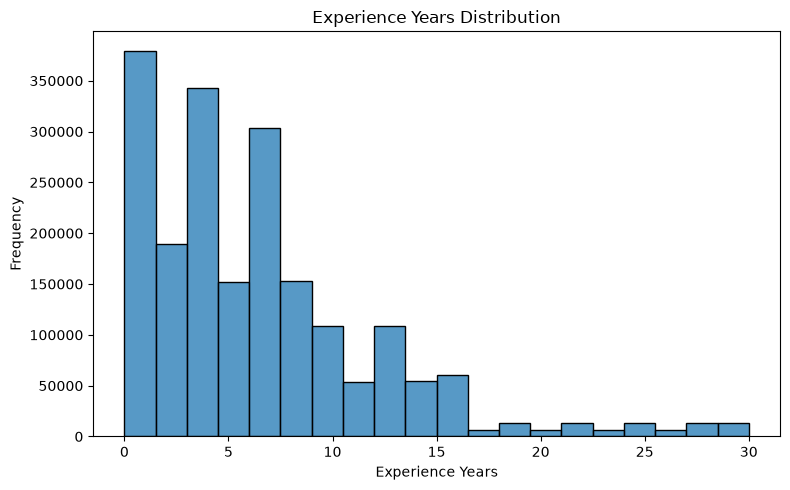

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x='experience_years',
    bins=20)

plt.title('Experience Years Distribution')
plt.xlabel('Experience Years')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [52]:
df['age'].describe()

count    2.000000e+06
mean     3.141359e+01
std      6.736600e+00
min      2.100000e+01
25%      2.700000e+01
50%      3.000000e+01
75%      3.500000e+01
max      6.600000e+01
Name: age, dtype: float64

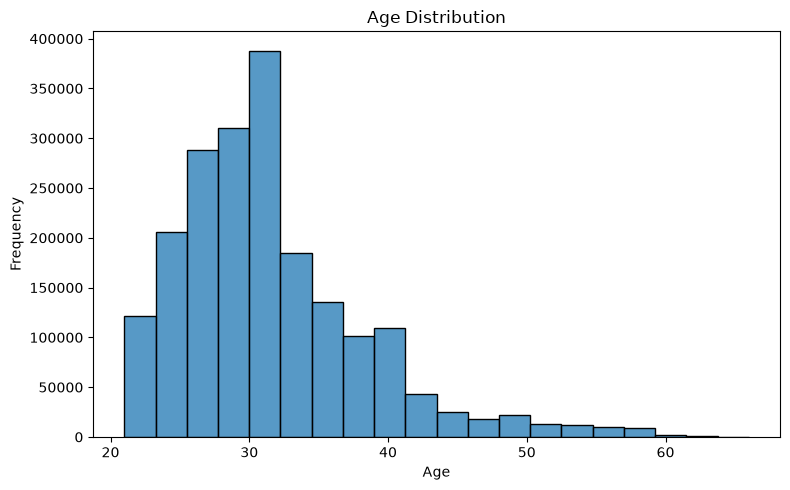

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x='age',
    bins=20)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [58]:
salary_joblevel = (df.groupby('job_level')['salary']
    .median().reset_index()
    .sort_values('salary', ascending=False))

salary_joblevel

,job_level,salary
0,Director,225491.5
3,Senior,140860.5
2,Mid,86310.0
1,Junior,50426.0


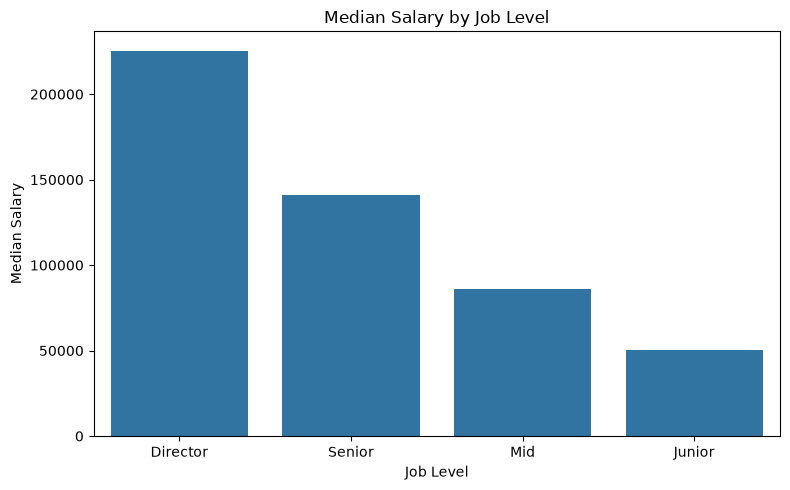

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=salary_joblevel,
    x='job_level',
    y='salary')

plt.title('Median Salary by Job Level')
plt.xlabel('Job Level')
plt.ylabel('Median Salary')
plt.tight_layout()
plt.show()

In [ ]:
experience_salary = (
    df.groupby('experience_years')['salary']
    .agg(['count','mean','median'])
    .reset_index())

experience_salary

,experience_years,count,mean,median
0,0,189322,50202.426062,49814.5
1,1,190288,50723.635048,50238.0
2,2,189690,51080.186562,50652.0
3,3,190031,51510.923149,51083.0
4,4,152746,84258.188496,84477.0
5,5,152454,85079.359420,85282.0
6,6,152392,86041.917679,86272.0
7,7,151179,87022.702842,87241.0
8,8,152696,88147.820290,88337.0
9,9,54270,135694.593062,135461.0


In [ ]:
df[['experience_years','salary']].corr()

,experience_years,salary
experience_years,1.000000,0.932785
salary,0.932785,1.000000


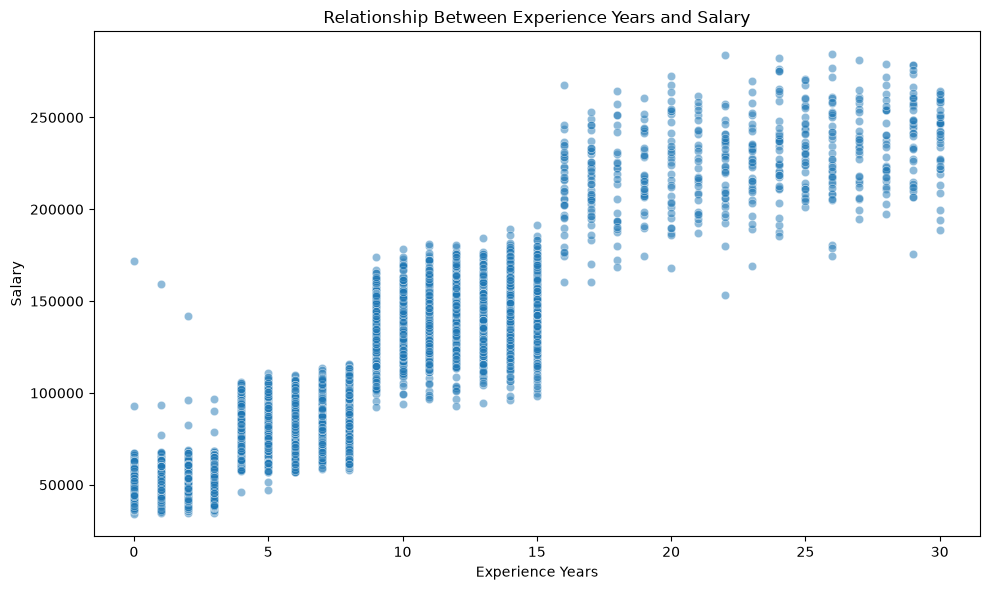

In [62]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df.sample(10000),
    x='experience_years',
    y='salary',
    alpha=0.5)

plt.title('Relationship Between Experience Years and Salary')
plt.xlabel('Experience Years')
plt.ylabel('Salary')
plt.tight_layout()
plt.show()

In [63]:
experience_joblevel = (df.groupby('job_level')['experience_years']
    .agg(['count','mean','median','min','max']).reset_index())

experience_joblevel

,job_level,count,mean,median,min,max
0,Director,100720,22.972865,23.0,0,30
1,Junior,758236,1.502532,2.0,0,5
2,Mid,761754,5.994108,6.0,0,8
3,Senior,379290,11.981057,12.0,0,15


In [64]:
experience_median = (
    df.groupby('job_level')['experience_years'].median()
    .reindex(['Junior','Mid','Senior','Director']))

experience_median

job_level
Junior       2.0
Mid          6.0
Senior      12.0
Director    23.0
Name: experience_years, dtype: float64

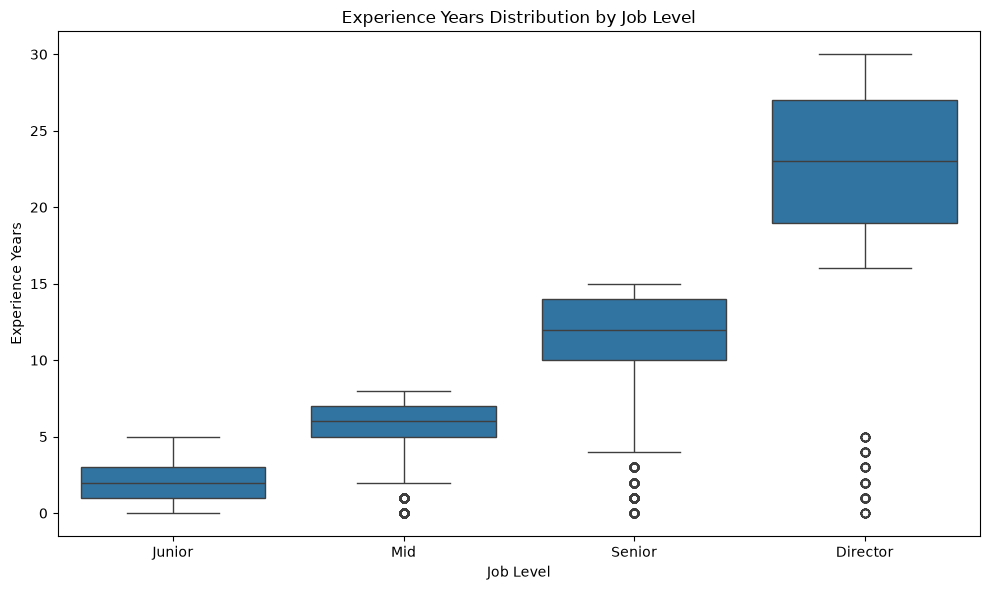

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='job_level',
    y='experience_years',
    order=['Junior','Mid','Senior','Director'])

plt.title('Experience Years Distribution by Job Level')
plt.xlabel('Job Level')
plt.ylabel('Experience Years')
plt.tight_layout()
plt.show()

In [66]:
age_joblevel = (
    df.groupby('job_level')['age']
    .agg(['count','mean','median','min','max']).reset_index())

age_joblevel

,job_level,count,mean,median,min,max
0,Director,100720,50.005143,50.0,36,66
1,Junior,758236,26.175470,26.0,21,39
2,Mid,761754,30.985589,31.0,24,44
3,Senior,379290,37.807672,38.0,29,51


In [ ]:
age_median = (
    df.groupby('job_level')['age'].median()
    .reindex(['Junior','Mid','Senior','Director']))

age_median

job_level
Junior      26.0
Mid         31.0
Senior      38.0
Director    50.0
Name: age, dtype: float64

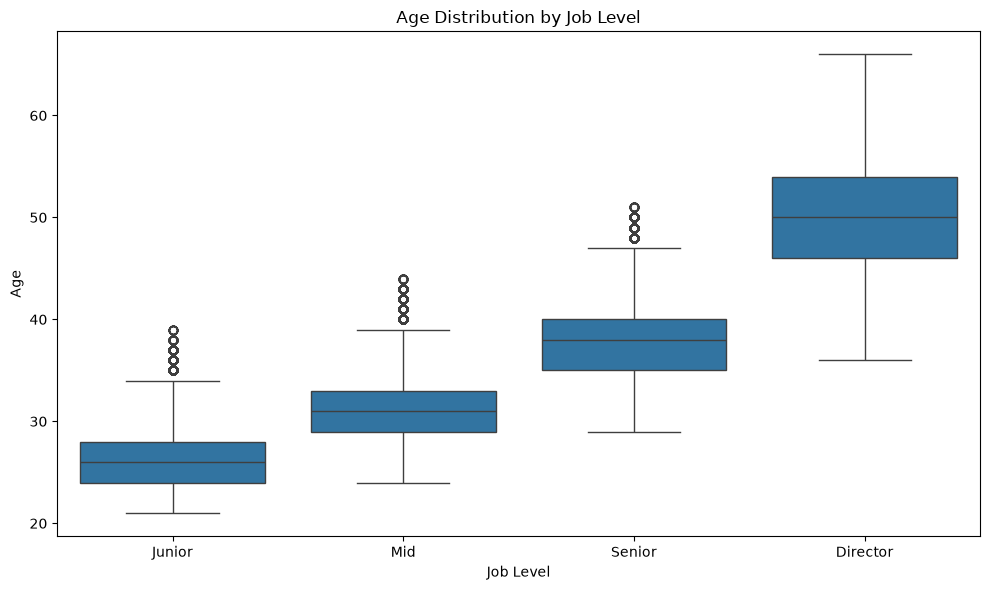

In [68]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='job_level',
    y='age',
    order=['Junior','Mid','Senior','Director'])

plt.title('Age Distribution by Job Level')
plt.xlabel('Job Level')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

In [70]:
performance_joblevel = (
    df.groupby(['job_level', 'performance_rating']).size()
    .reset_index(name='total_employee'))

performance_joblevel_pct = (
    performance_joblevel
    .assign(
        percentage=lambda x:
        x['total_employee']
        / x.groupby('job_level')['total_employee'].transform('sum')
        * 100))

performance_joblevel_pct

,job_level,performance_rating,total_employee,percentage
0,Director,Excellent,14820,14.714059
1,Director,Good,50302,49.942415
2,Director,Needs Improvement,7070,7.019460
3,Director,Satisfactory,28349,28.146346
4,Director,Unknown,179,0.177720
5,Junior,Excellent,113271,14.938753
6,Junior,Good,379000,49.984438
7,Junior,Needs Improvement,53047,6.996107
8,Junior,Satisfactory,211640,27.912154
9,Junior,Unknown,1278,0.168549


In [71]:
performance_pct_table = (
    pd.crosstab(
        df['job_level'],
        df['performance_rating'],
        normalize='index') * 100)

performance_pct_table

performance_rating,Excellent,Good,Needs Improvement,Satisfactory,Unknown
job_level,,,,,
Director,14.714059,49.942415,7.019460,28.146346,0.177720
Junior,14.938753,49.984438,6.996107,27.912154,0.168549
Mid,14.946558,49.905744,7.009612,27.976355,0.161732
Senior,15.000923,49.963616,6.963273,27.902397,0.169791


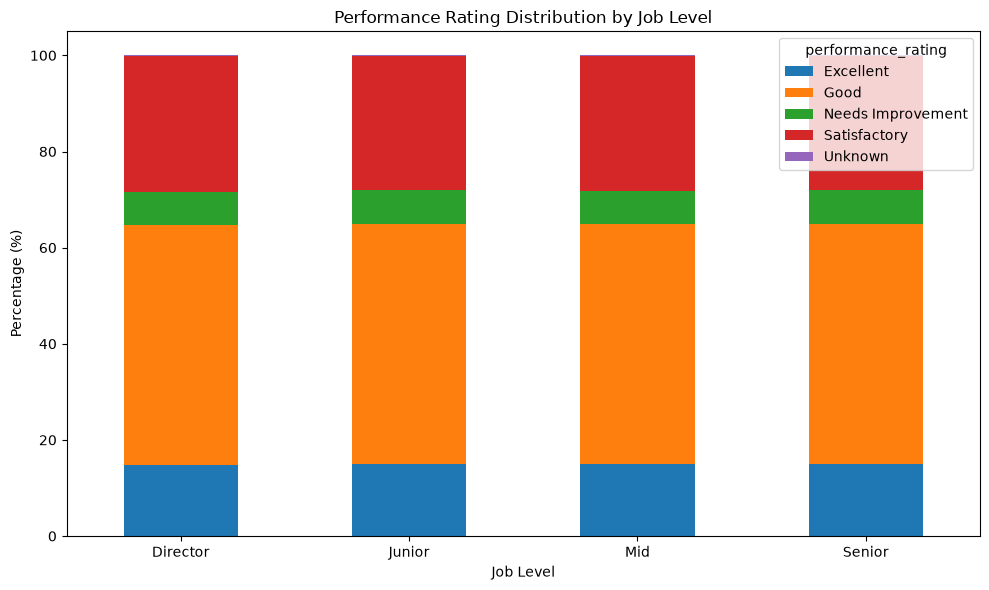

In [72]:
performance_pct_table.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6))

plt.title('Performance Rating Distribution by Job Level')
plt.xlabel('Job Level')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [73]:
workmode_department = (
    df.groupby(['department', 'work_mode']).size()
    .reset_index(name='total_employee'))

workmode_department_pct = (
    workmode_department
    .assign(
        percentage=lambda x:
        x['total_employee']
        / x.groupby('department')['total_employee'].transform('sum')
        * 100))

workmode_department_pct

,department,work_mode,total_employee,percentage
0,Finance,Hybrid,45345,15.117268
1,Finance,On-site,179613,59.879982
2,Finance,Remote,74997,25.002750
3,HR,Hybrid,29898,14.987067
4,HR,On-site,119570,59.937241
5,HR,Remote,50024,25.075692
6,IT,Hybrid,125052,25.044210
7,IT,On-site,200004,40.054874
8,IT,Remote,174269,34.900916
9,Operations,Hybrid,60115,15.006428


In [75]:
workmode_pct_table = (
    pd.crosstab(df['department'],df['work_mode'],normalize='index')
      * 100)

workmode_pct_table

work_mode,Hybrid,On-site,Remote
department,,,
Finance,15.117268,59.879982,25.002750
HR,14.987067,59.937241,25.075692
IT,25.044210,40.054874,34.900916
Operations,15.006428,59.881676,25.111896
Sales,15.008666,59.982885,25.008449


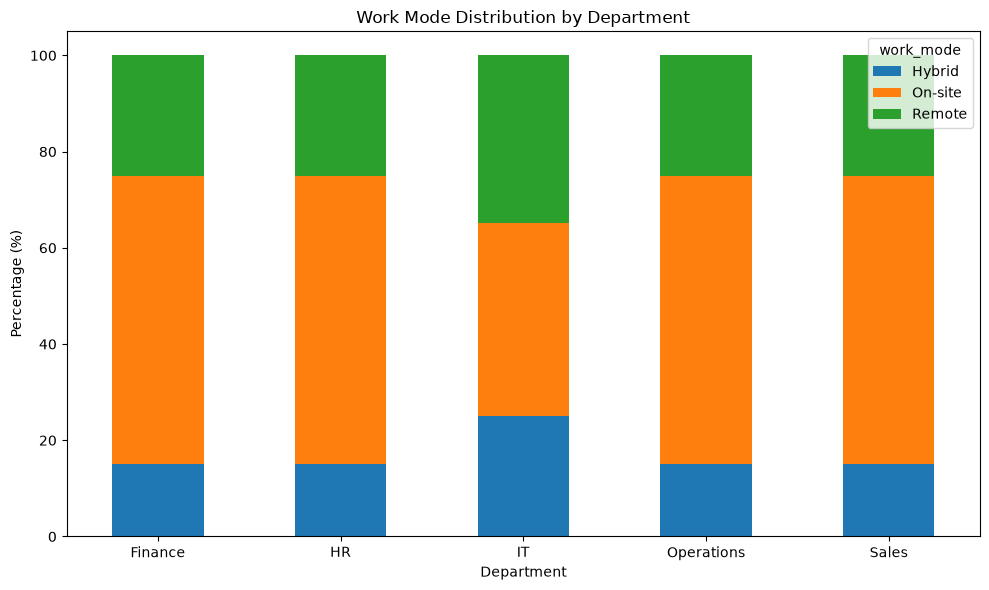

In [76]:
workmode_pct_table.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6))

plt.title('Work Mode Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [78]:
df.to_csv('hr_clean.csv',index=False)